# Correction : première régression linéaire

On entraîne une régression linéaire pour prédire le prix d'un logement à partir de sa surface.

In [2]:
import pandas as pd

data = pd.DataFrame({
    "surface": [30, 40, 50, 60, 70, 80, 90, 100, 110],
    "prix": [120000, 160000, 200000, 240000, 280000, 320000, 360000, 400000, 440000]
})

data

,surface,prix
0,30,120000
1,40,160000
2,50,200000
3,60,240000
4,70,280000
5,80,320000
6,90,360000
7,100,400000
8,110,440000


## 1. Séparer les features et le label

`X` contient les données utilisées pour prédire.

`y` contient la valeur à prédire.

Cette étape sépare les colonnes, mais ne découpe pas encore le dataset en train/test.

In [3]:
X = data[["surface"]]
y = data["prix"]

X

,surface
0,30
1,40
2,50
3,60
4,70
5,80
6,90
7,100
8,110


## 2. Séparer entraînement et test

On sépare le dataset initial en deux parties :

- une partie pour entraîner le modèle ;
- une partie pour tester le modèle.

Ici, on garde `20%` des données pour le test.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Taille de X_train :", X_train.shape)
print("Taille de X_test  :", X_test.shape)

Taille de X_train : (7, 1)
Taille de X_test  : (2, 1)


`test_size=0.2` signifie que l'on garde environ `20%` des données pour le test et `80%` pour l'entraînement.

Ce n'est pas une règle obligatoire, c'est une convention pratique.

L'idée est de donner assez de données au modèle pour apprendre, tout en gardant des exemples jamais vus pour mesurer son erreur.

Avec ce petit dataset, le jeu de test contient seulement quelques lignes. C'est utile pour comprendre le principe, mais ce n'est pas une évaluation très robuste.

## 3. Entraîner le modèle

Le modèle apprend uniquement à partir de `X_train` et `y_train`.

Les données de test restent de côté.

In [5]:
from sklearn.linear_model import LinearRegression

modele = LinearRegression()
modele.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[4000.]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['surface']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.821e-11
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


La ligne `modele.fit(X_train, y_train)` veut dire :

```text
Apprends la relation entre la surface et le prix.
```

## 3. Lire ce que le modèle a appris

In [6]:
coefficient = modele.coef_[0]
intercept = modele.intercept_

coefficient, intercept

(np.float64(3999.999999999999), np.float64(5.820766091346741e-11))

Le modèle apprend une formule du type :

```text
prix = coefficient × surface + intercept
```

Ici, le coefficient vaut `4000`.

Cela signifie que, dans ce jeu de données, chaque m² supplémentaire augmente le prix d'environ `4000 €`.

L'intercept vaut environ `0`, donc la formule apprise est :

```text
prix = 4000 × surface
```

## 4. Faire une prédiction

In [7]:
nouveau_logement = pd.DataFrame({
    "surface": [75]
})

prix_predit = modele.predict(nouveau_logement)
prix_predit

array([300000.])

Le modèle prédit environ `300000 €` pour un logement de `75 m²`.

## 5. Vérifier avec la formule

In [8]:
prix_calcule = coefficient * 75 + intercept
prix_calcule

np.float64(300000.0)

Le calcul manuel donne le même résultat que `modele.predict(...)`.

C'est important : une régression linéaire reste un modèle interprétable. On peut lire la formule qu'il a apprise.

## 6. Tester le modèle

Les données de test n'ont pas servi à entraîner le modèle.

On les utilise pour vérifier si le modèle prédit correctement des exemples qu'il n'a pas vus pendant l'entraînement.

In [9]:
from sklearn.metrics import mean_absolute_error

predictions_test = modele.predict(X_test)
mae_test = mean_absolute_error(y_test, predictions_test)

print("Vrais prix test :", list(y_test))
print("Prix prédits    :", list(predictions_test))
print("Erreur moyenne  :", mae_test)

Vrais prix test : [400000, 160000]
Prix prédits    : [np.float64(399999.99999999994), np.float64(160000.00000000003)]
Erreur moyenne  : 4.3655745685100555e-11


La MAE test indique de combien le modèle se trompe en moyenne sur des données qu'il n'a pas utilisées pour apprendre.

C'est l'intérêt du jeu de test : il donne une première estimation de la performance du modèle sur de nouvelles données. 

Le modèle semble très performant sur le jeu de test, mais le jeu de test ne contient que deux observations. On ne peut donc pas conclure que le modèle généralisera correctement sur de nouvelles données. Pour évaluer la performance de manière fiable, il faudrait davantage de données ou utiliser une validation croisée.

## 7. Visualiser la droite

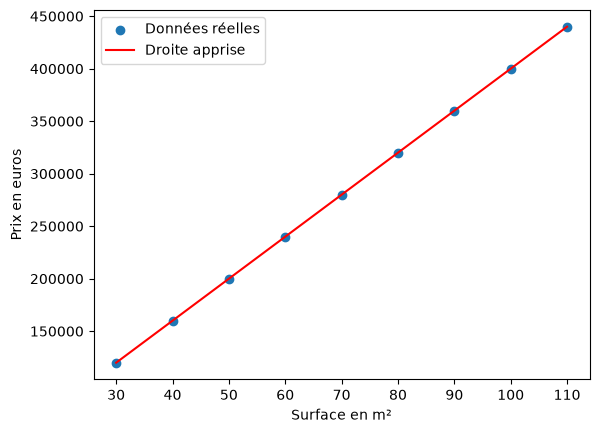

In [10]:
import matplotlib.pyplot as plt

prix_predits = modele.predict(X)

plt.scatter(data["surface"], data["prix"], label="Données réelles")
plt.plot(data["surface"], prix_predits, color="red", label="Droite apprise")
plt.xlabel("Surface en m²")
plt.ylabel("Prix en euros")
plt.legend()
plt.show()

## Conclusion

La régression linéaire apprend une relation simple entre une ou plusieurs features et une valeur à prédire.

Dans cet exercice :

- feature : `surface` ;
- label : `prix` ;
- coefficient : environ `4000` ;
- prédiction pour `75 m²` : environ `300000 €`.
- MAE test : erreur moyenne du modèle sur les données qu'il n'a pas vues pendant l'entraînement.

`fit` sert à entraîner le modèle.

`predict` sert à utiliser le modèle entraîné pour prédire une nouvelle valeur.